Building End to End ML Model - Binary Classification

In [1]:
#importing necessary dependencies
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#loading the data
data=pd.read_csv("/content/LoanApprovalPrediction+.csv")

In [3]:
data.head() #first 5 records by default

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            598 non-null    object 
 1   Gender             598 non-null    object 
 2   Married            598 non-null    object 
 3   Dependents         586 non-null    float64
 4   Education          598 non-null    object 
 5   Self_Employed      598 non-null    object 
 6   ApplicantIncome    598 non-null    int64  
 7   CoapplicantIncome  598 non-null    float64
 8   LoanAmount         577 non-null    float64
 9   Loan_Amount_Term   584 non-null    float64
 10  Credit_History     549 non-null    float64
 11  Property_Area      598 non-null    object 
 12  Loan_Status        598 non-null    object 
dtypes: float64(5), int64(1), object(7)
memory usage: 60.9+ KB


In [6]:
data.isnull().sum() #Dependents, LoanAmount, Loan_Amount_Term, Credit_History have null values that are supposed to be treated

,0
Loan_ID,0
Gender,0
Married,0
Dependents,12
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,21
Loan_Amount_Term,14


In [7]:
#dropping the Loan_ID column because it is just an identifier
data=data.drop(['Loan_ID'],axis=1)

In [8]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [9]:
#replacing missing values from the numeric columns by using SimpleImputer
from sklearn.impute import SimpleImputer

In [10]:
num_cols=data.select_dtypes(include=np.number).columns #numeric columns

In [11]:
print(num_cols)

Index(['Dependents', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')


In [12]:
num_imputer=SimpleImputer(strategy='median') #replacing the missing values with the median of the given col
data[num_cols]=num_imputer.fit_transform(data[num_cols])
#logic of replacing the missing values with the median is applied across all the numeric cols of the dataset

In [13]:
data.isnull().sum() #missing values from the dataset is now handled

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [15]:
data.head() #now, categorical columns from the dataset needs to be handled

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849.0,0.0,127.0,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y


In order to convert categorical columns to numeric we can use any one of the following:

- Label Encoder
- One-Hot Encoder

In [16]:
cat_cols=data.select_dtypes(include='object').columns #categorical columns
print(cat_cols)

Index(['Gender', 'Married', 'Education', 'Self_Employed', 'Property_Area',
       'Loan_Status'],
      dtype='object')


In [17]:
data['Gender'].unique()

array(['Male', 'Female'], dtype=object)

In [18]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

In [19]:
data['Gender']=le.fit_transform(data['Gender'])

In [20]:
data['Gender'].unique() #Male gets replaced by 1 and Female gets replaced by 0

array([1, 0])

In [21]:
data['Property_Area'].unique()

array(['Urban', 'Rural', 'Semiurban'], dtype=object)

In [22]:
data['Property_Area']=le.fit_transform(data['Property_Area'])

In [25]:
data['Property_Area'].unique()
#Urban gets replaced by 2, Rural gets replaced by 0 and SemiUrban gets replaced by 1

array([2, 0, 1])

In [26]:
data['Loan_Status']=le.fit_transform(data['Loan_Status'])

In [27]:
data['Married']=le.fit_transform(data['Married'])

In [28]:
data['Education']=le.fit_transform(data['Education'])

In [29]:
data['Self_Employed']=le.fit_transform(data['Self_Employed'])

In [30]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0.0,0,0,5849.0,0.0,127.0,360.0,1.0,2,1
1,1,1,1.0,0,0,4583.0,1508.0,128.0,360.0,1.0,0,0
2,1,1,0.0,0,1,3000.0,0.0,66.0,360.0,1.0,2,1
3,1,1,0.0,1,0,2583.0,2358.0,120.0,360.0,1.0,2,1
4,1,0,0.0,0,0,6000.0,0.0,141.0,360.0,1.0,2,1


In [32]:
loan_counts=data['Loan_Status'].value_counts()
#411 customers got the loan application approved and 187 customers were not able to get the loan application approved

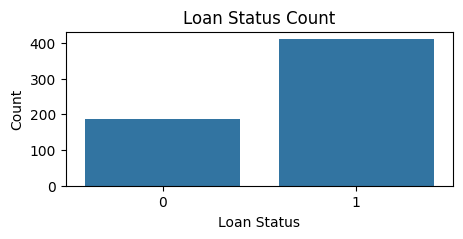

In [33]:
plt.figure(figsize=(5,2))
sns.barplot(x=loan_counts.index, y=loan_counts.values)
plt.title('Loan Status Count')
plt.xlabel('Loan Status')
plt.ylabel('Count')

plt.show()

In [34]:
#Dividing the data into 'X' [input independent columns] and 'y' [output dependent columns]
X=data.drop(['Loan_Status'],axis=1) #input independent columns, exluding the target column
y=data['Loan_Status'] #output dependent (target) column

In [42]:
#Splitting the data into training and testing
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)
#20% of the data is used for evaluating the performance and rest 80% data is used for training the model

In [43]:
#Since we are building a Binary Classifier, we plan to choose - Logistic Regression
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()

In [44]:
model.fit(X_train,y_train) #using the .fit() - training of the ML model takes place
#here x_train represents - i/p columns and y_train represents - o/p column (Supervised ML model)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [45]:
y_hat=model.predict(X_test) #the output from .predict() will the predictions of the ML Model
#the quality of this predicted output is something that we test when we check for the accuracy of the ML Model

In [46]:
#checking the performance of the ML Model
from sklearn.metrics import confusion_matrix, accuracy_score
cm=confusion_matrix(y_hat,y_test) #y_hat is the predicted values and y_test is the actual value
print(cm) #TP - 13, TN - 57, FP - 1 and FN - 19

[[19  1]
 [21 79]]


In [47]:
ac=accuracy_score(y_hat,y_test)
print(ac)

0.8166666666666667
